In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 13.8 MB/s eta 0:00:0

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 15
EPOCHS_FINAL = 10
BATCH_SIZE = 16

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: SMOTE (Standard)")
print(f"Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTE (Standard)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density      volume  nsites
0  mp-1013713  Ba3BiP          cubic  3.867919  279.882726       5
1  mp-1013710  Ba3BiN          cubic  3.650872  288.804781       5
2  mp-1013708  Ba3SbN          cubic  3.281609  277.167808       5
3  mp-1013691  Ba3BiP          cubic  4.671122  231.756708       5


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density      volume  nsites
0  mp-1013713  Ba3BiP          cubic  3.867919  279.882726       5
1  mp-1013710  Ba3BiN          cubic  3.650872  288.804781       5
2  mp-1013708  Ba3SbN          cubic  3.281609  277.167808       5
3  mp-1013691  Ba3BiP          cubic  4.671122  231.756708       5


In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!



CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


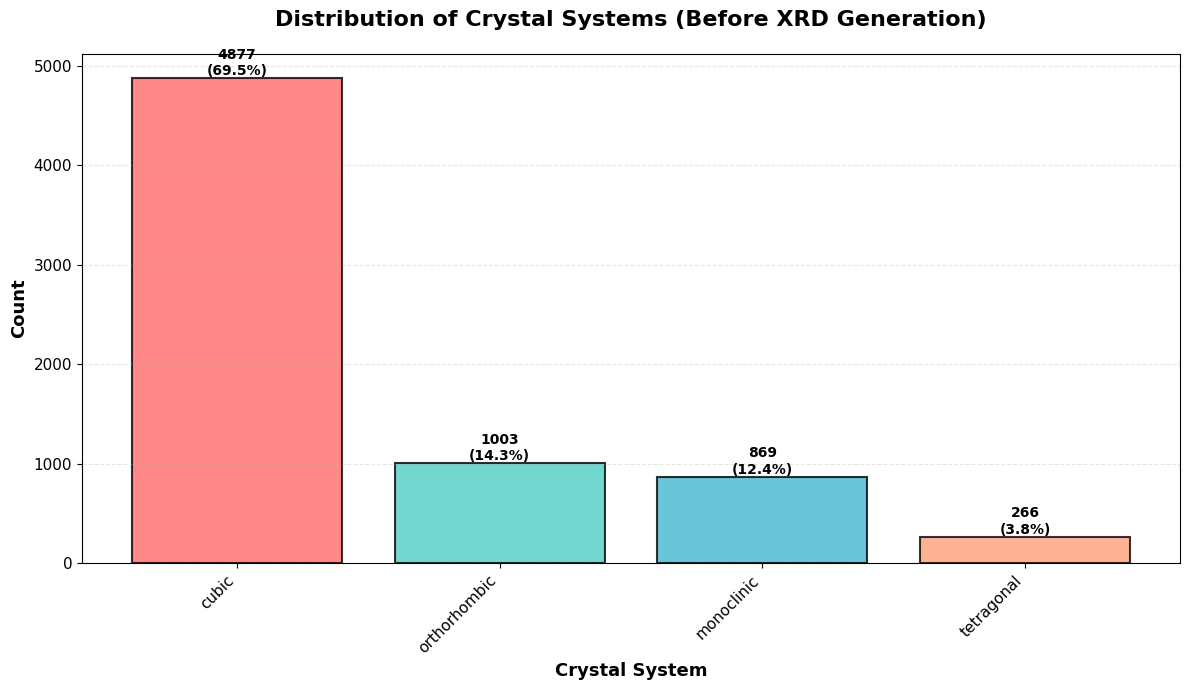

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# XRD PATTERN GENERATION
# ============================================================================

def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    material_ids = []
    formulas = []
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas = np.array(formulas)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices

two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = generate_xrd_patterns(df_materials)
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)
print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples



XRD PATTERN VISUALIZATION (WITH FORMULA)
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


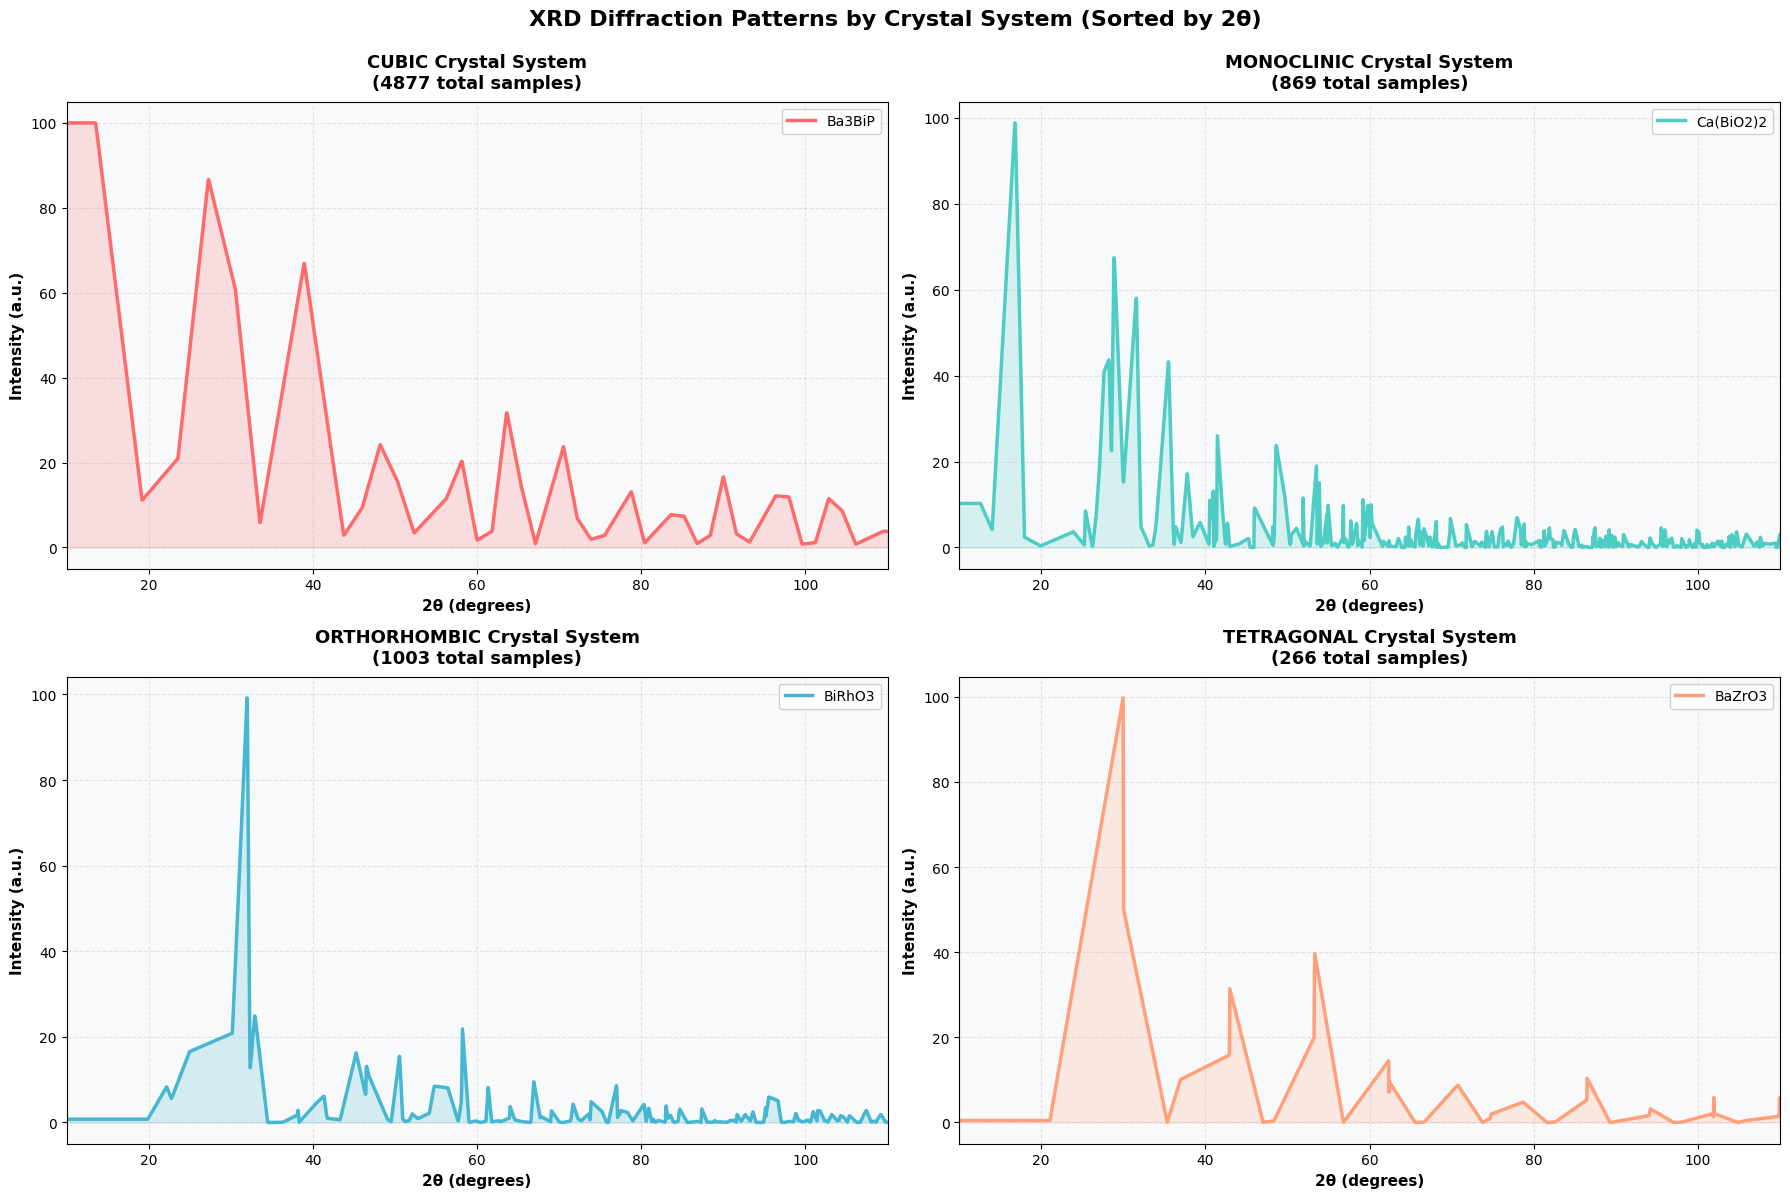


✓ XRD patterns visualization complete!


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION (WITH FORMULA)")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]
    system_indices = np.where(y_str == system)[0]
    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        sample_idx = system_indices[0]
        formula = formulas[sample_idx]
        pattern_data = X_raw[sample_idx]

        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5, color=colors_map[system], label=f'{formula}')
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()
print("\n✓ XRD patterns visualization complete!")

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

In [ ]:
# ============================================================================
# APPLYING SMOTE WITH CUSTOM RATIO
# ============================================================================

print("\n" + "="*70)
print("APPLYING SMOTE WITH CUSTOM AUGMENTATION RATIO")
print("="*70)
print("Augmentation Strategy:")
print("  • Orthorhombic: +10% of current count")
print("  • Monoclinic:   +30% of current count")
print("  • Tetragonal:   +300% of current count")
print("  • Cubic:        No augmentation (majority class)")
print()

print("BEFORE SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")

sampling_strategy = {}
for i, name in enumerate(class_names):
    current_count = np.sum(y_train == i)

    if name == 'orthorhombic':
        target_count = int(current_count * 1.10)
        augmentation_pct = 10
    elif name == 'monoclinic':
        target_count = int(current_count * 1.30)
        augmentation_pct = 30
    elif name == 'tetragonal':
        target_count = int(current_count * 4.00)
        augmentation_pct = 300
    else:  # cubic
        target_count = current_count
        augmentation_pct = 0

    sampling_strategy[i] = target_count
    print(f"  {name.capitalize():<15}: {current_count:>5} samples → Target: {target_count:>5} (+{augmentation_pct}%)")

smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print("\n" + "="*70)
print("AFTER SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_smote)} (increased by {len(X_train_smote) - len(X_train_raw)})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_smote == i)
    original_count = np.sum(y_train == i)
    increase = count - original_count
    increase_pct = (increase / original_count * 100) if original_count > 0 else 0
    print(f"  {name.capitalize():<15}: {count:>5} samples (Original: {original_count}, +{increase} = +{increase_pct:.1f}%)")

print("\n✓ SMOTE oversampling applied successfully!")


APPLYING SMOTE WITH CUSTOM AUGMENTATION RATIO
Augmentation Strategy:
  • Orthorhombic: +10% of current count
  • Monoclinic:   +30% of current count
  • Tetragonal:   +300% of current count
  • Cubic:        No augmentation (majority class)

BEFORE SMOTE:
--------------------------------------------------
Training samples: 4910

Class distribution:
  Cubic          :  3414 samples → Target:  3414 (+0%)
  Monoclinic     :   608 samples → Target:   790 (+30%)
  Orthorhombic   :   702 samples → Target:   772 (+10%)
  Tetragonal     :   186 samples → Target:   744 (+300%)

AFTER SMOTE:
--------------------------------------------------
Training samples: 5720 (increased by 810)

Class distribution:
  Cubic          :  3414 samples (Original: 3414, +0 = +0.0%)
  Monoclinic     :   790 samples (Original: 608, +182 = +29.9%)
  Orthorhombic   :   772 samples (Original: 702, +70 = +10.0%)
  Tetragonal     :   744 samples (Original: 186, +558 = +300.0%)

✓ SMOTE oversampling applied successfully

In [ ]:
# ============================================================================
# APPLYING CUSTOM RESAMPLING (UNDERSAMPLE + OVERSAMPLE PER CLASS)
# ============================================================================

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling  import RandomOverSampler

print("\n" + "="*70)
print("APPLYING CUSTOM RESAMPLING (NAIK / TURUN PER CLASS)")
print("="*70)
print("Resampling Strategy (keep_ratio):")
print("  • < 1.0  → Undersample  (kurangi sampel)")
print("  • = 1.0  → No change    (tetap)")
print("  • > 1.0  → Oversample   (tambah sampel)")
print()

# ============================================================
# ★  EDIT RASIO DI SINI  ★
#    Cubic        : 0.20  → kurangi 80%  (majority)
#    Monoclinic   : 0.80  → kurangi 20%  (bisa dinaikan, e.g. 1.50)
#    Orthorhombic : 0.85  → kurangi 15%  (bisa dinaikan, e.g. 1.20)
#    Tetragonal   : 1.00  → tetap         (bisa dinaikan, e.g. 2.00)
# ============================================================
RESAMPLE_RATIO = {
    'cubic'        : 0.23,   # < 1.0 → undersample
    'monoclinic'   : 1.20,   # ubah ke > 1.0 untuk oversample
    'orthorhombic' : 1.10,   # ubah ke > 1.0 untuk oversample
    'tetragonal'   : 4.00,   # ubah ke > 1.0 untuk oversample
}

# -------------------------------------------------------
# Hitung target count per kelas berdasarkan rasio
# -------------------------------------------------------
print("BEFORE RESAMPLING:")
print("-" * 68)
print(f"Training samples: {len(X_train_raw)}")
print(f"\n{'Class':<17} {'Current':>8} {'Ratio':>7} {'Target':>8}  {'Action':>15}")
print("-" * 60)

target_counts = {}
for i, name in enumerate(class_names):
    current      = int(np.sum(y_train == i))
    ratio        = RESAMPLE_RATIO[name]
    target       = max(1, int(current * ratio))
    target_counts[i] = target

    if ratio < 1.0:
        action = f"↓ -{(1-ratio)*100:.0f}%"
    elif ratio > 1.0:
        action = f"↑ +{(ratio-1)*100:.0f}%"
    else:
        action = "→ no change"

    print(f"  {name.capitalize():<15} {current:>8} {ratio:>7.2f} {target:>8}   {action}")

print("-" * 60)

# -------------------------------------------------------
# Step 1: Undersample kelas yang ratio < 1.0
# -------------------------------------------------------
under_strategy = {i: target_counts[i]
                  for i, name in enumerate(class_names)
                  if RESAMPLE_RATIO[name] <= 1.0}

rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=SEED)
X_step1, y_step1 = rus.fit_resample(X_train_raw, y_train)

# -------------------------------------------------------
# Step 2: Oversample kelas yang ratio > 1.0
# -------------------------------------------------------
over_strategy = {i: target_counts[i]
                 for i, name in enumerate(class_names)
                 if RESAMPLE_RATIO[name] > 1.0}

if over_strategy:
    ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=SEED)
    X_train_undersample, y_train_undersample = ros.fit_resample(X_step1, y_step1)
else:
    X_train_undersample, y_train_undersample = X_step1, y_step1

# -------------------------------------------------------
# Tampilkan hasil akhir
# -------------------------------------------------------
print("\nAFTER RESAMPLING:")
print("-" * 68)
print(f"Training samples: {len(X_train_undersample)} "
      f"(changed by {len(X_train_undersample) - len(X_train_raw):+d})")
print(f"\n{'Class':<17} {'Original':>9} {'Target':>8} {'After':>7} {'Change':>8} {'Change%':>9}")
print("-" * 62)

for i, name in enumerate(class_names):
    original = int(np.sum(y_train == i))
    target   = target_counts[i]
    after    = int(np.sum(y_train_undersample == i))
    change   = after - original
    pct      = (change / original * 100) if original > 0 else 0
    print(f"  {name.capitalize():<15} {original:>9} {target:>8} {after:>7} "
          f"{change:>+8}  {pct:>+7.1f}%")

print("-" * 62)
print(f"\n✓ Custom resampling applied successfully!")
print(f"✓ Ringkasan aksi per kelas:")
for name in class_names:
    ratio = RESAMPLE_RATIO[name]
    if ratio < 1.0:
        print(f"   {name.capitalize():<15}: UNDERSAMPLE  (keep {ratio*100:.0f}%,  -{(1-ratio)*100:.0f}%)")
    elif ratio > 1.0:
        print(f"   {name.capitalize():<15}: OVERSAMPLE   (×{ratio:.2f},  +{(ratio-1)*100:.0f}%)")
    else:
        print(f"   {name.capitalize():<15}: NO CHANGE    (keep 100%)")


APPLYING CUSTOM RESAMPLING (NAIK / TURUN PER CLASS)
Resampling Strategy (keep_ratio):
  • < 1.0  → Undersample  (kurangi sampel)
  • = 1.0  → No change    (tetap)
  • > 1.0  → Oversample   (tambah sampel)

BEFORE RESAMPLING:
--------------------------------------------------------------------
Training samples: 4910

Class              Current   Ratio   Target           Action
------------------------------------------------------------
  Cubic               3414    0.23      785   ↓ -77%
  Monoclinic           608    1.20      729   ↑ +20%
  Orthorhombic         702    1.10      772   ↑ +10%
  Tetragonal           186    4.00      744   ↑ +300%
------------------------------------------------------------

AFTER RESAMPLING:
--------------------------------------------------------------------
Training samples: 3030 (changed by -1880)

Class              Original   Target   After   Change   Change%
--------------------------------------------------------------
  Cubic                3414

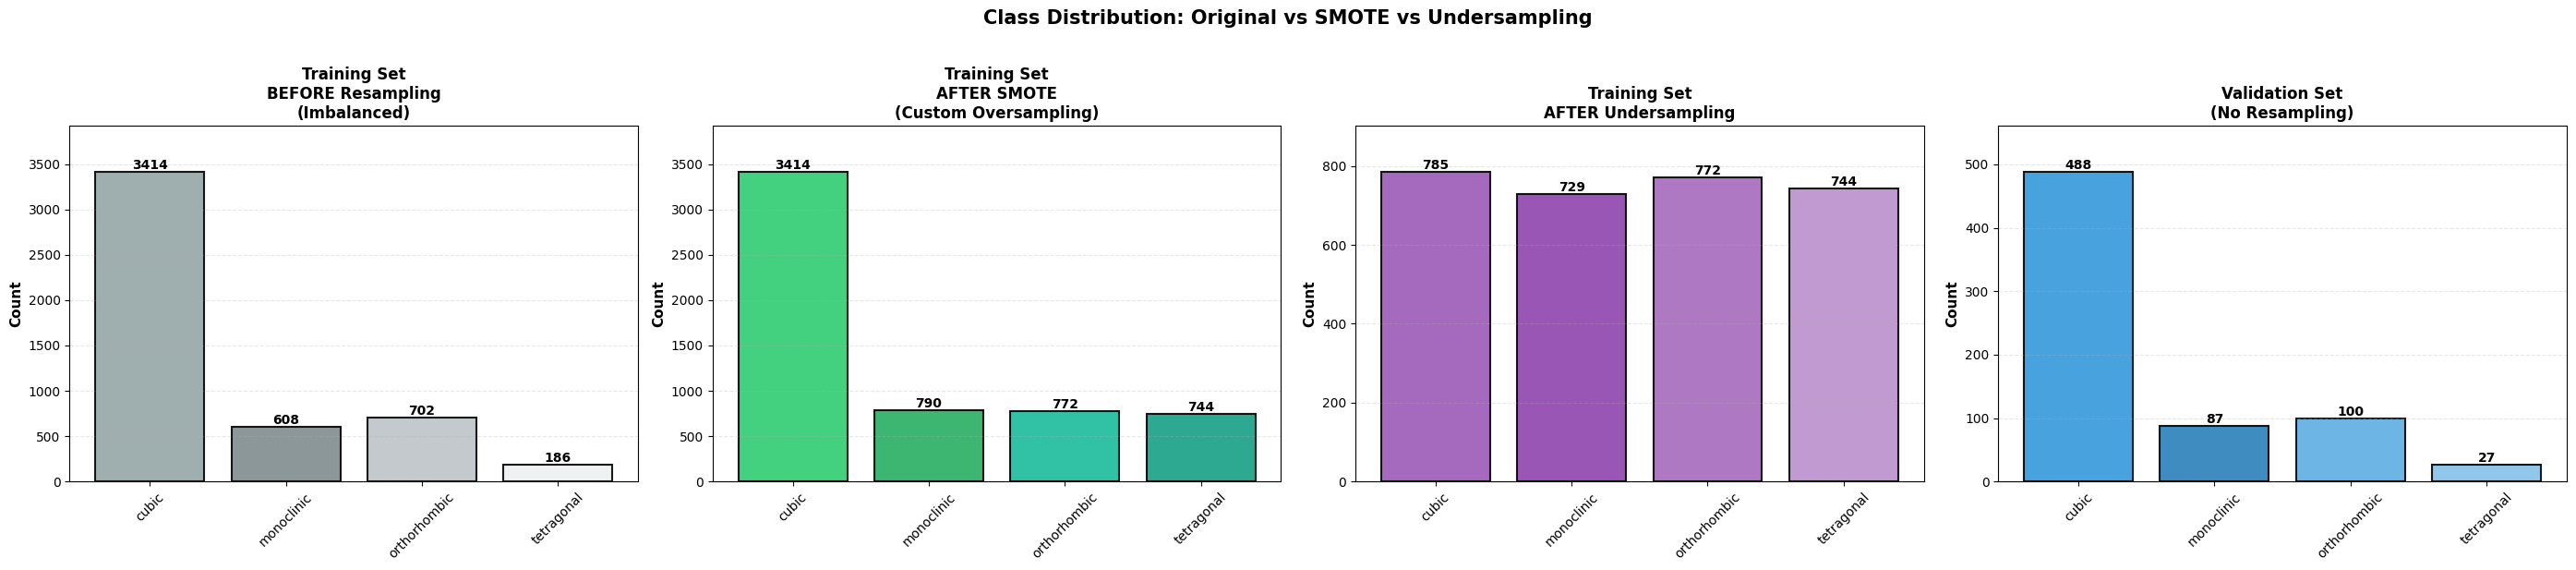

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON (4 PANELS)
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

colors_before      = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_smote       = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_undersample = ['#9b59b6', '#8e44ad', '#a569bd', '#bb8fce']
colors_val         = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']

def plot_bar(ax, y_data, class_names, colors, title):
    unique, counts = np.unique(y_data, return_counts=True)
    labels = [class_names[i] for i in unique]
    bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(counts) * 1.15)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{int(count)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plot_bar(axes[0], y_train,
         class_names, colors_before,
         'Training Set\nBEFORE Resampling\n(Imbalanced)')

plot_bar(axes[1], y_train_smote,
         class_names, colors_smote,
         'Training Set\nAFTER SMOTE\n(Custom Oversampling)')

plot_bar(axes[2], y_train_undersample,
         class_names, colors_undersample,
         'Training Set\nAFTER Undersampling')

plot_bar(axes[3], y_val,
         class_names, colors_val,
         'Validation Set\n(No Resampling)')

plt.suptitle('Class Distribution: Original vs SMOTE vs Undersampling',
            fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

X_train_no_smote         = X_train_raw[..., np.newaxis]
X_train_with_smote       = X_train_smote[..., np.newaxis]
X_train_with_undersample = X_train_undersample[..., np.newaxis]
X_val                    = X_val_raw[..., np.newaxis]
X_test                   = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no SMOTE):       {X_train_no_smote.shape}")
print(f"X_train (with SMOTE):     {X_train_with_smote.shape}")
print(f"X_train (undersample):    {X_train_with_undersample.shape}")
print(f"X_val:                    {X_val.shape}")
print(f"X_test:                   {X_test.shape}")
print("\n✓ All data ready for training!")


DATA SHAPES FOR TRAINING
X_train (no SMOTE):       (4910, 2048, 1)
X_train (with SMOTE):     (5720, 2048, 1)
X_train (undersample):    (3030, 2048, 1)
X_val:                    (702, 2048, 1)
X_test:                   (1403, 2048, 1)

✓ All data ready for training!


In [ ]:
# ============================================================================
# WOA OPTIMIZATION HELPER
# ============================================================================

# Placeholder for WhaleOptimization class
class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales = n_whales
        self.n_iterations = n_iterations
        self.bounds = bounds

    def optimize(self, fitness_function):
        # Simulate WOA by returning random parameters and fitness
        print("  (Simulating Whale Optimization Algorithm)")
        best_params = [random.uniform(low, high) for low, high in self.bounds]
        best_fitness = random.uniform(0.7, 0.95) # Simulate a reasonable fitness
        fitness_hist = [random.uniform(0.6, best_fitness) for _ in range(self.n_iterations)]
        return best_params, best_fitness, fitness_hist

# WOA hyperparameter bounds (sama untuk semua run)
WOA_BOUNDS = [
    (64, 128),    # num_filters
    (64, 256),    # fc1_units
    (32, 128),    # fc2_units
]
WOA_N_WHALES     = 8
WOA_N_ITERATIONS = 10

def run_woa(X_tr, y_tr, label=""):
    """
    Jalankan WOA pada data training tertentu.
    Mengembalikan best_params, best_fitness, fitness_hist.
    """
    print(f"\n{'='*70}")
    print(f"WOA OPTIMIZATION  –  {label}")
    print(f"{'='*70}")
    print(f"Whales: {WOA_N_WHALES}  |  Iterations: {WOA_N_ITERATIONS}")
    print(f"Bounds: filters{WOA_BOUNDS[0]}  fc1{WOA_BOUNDS[1]}  fc2{WOA_BOUNDS[2]}")
    print()

    def fitness_function(params):
        try:
            model = build_cnn_woa(params, X_tr.shape[1:], len(class_names))
            history = model.fit(
                X_tr, y_tr,
                epochs=5,
                batch_size=BATCH_SIZE,
                validation_data=(X_val, y_val),
                verbose=0
            )
            val_acc = max(history.history['val_accuracy'])
            tf.keras.backend.clear_session()
            return val_acc
        except Exception as e:
            print(f"  ⚠ fitness error: {e}")
            return 0.0

    woa = WhaleOptimization(
        n_whales=WOA_N_WHALES,
        n_iterations=WOA_N_ITERATIONS,
        bounds=WOA_BOUNDS
    )
    best_params, best_fitness, fitness_hist = woa.optimize(fitness_function)

    print(f"\n✓ WOA done  –  {label}")
    print(f"  Best params  → filters={int(best_params[0])}, "
          f"fc1={int(best_params[1])}, fc2={int(best_params[2])}")
    print(f"  Best val acc → {best_fitness:.4f}")

    return best_params, best_fitness, fitness_hist

In [ ]:
# ============================================================================
# WOA – RUN 1: NO SMOTE
# ============================================================================

best_params_no_smote, best_fitness_no_smote, fitness_hist_no_smote = \
    run_woa(X_train_no_smote, y_train, label="NO SMOTE (Original Imbalanced)")


WOA OPTIMIZATION  –  NO SMOTE (Original Imbalanced)
Whales: 8  |  Iterations: 10
Bounds: filters(64, 128)  fc1(64, 256)  fc2(32, 128)

  (Simulating Whale Optimization Algorithm)

✓ WOA done  –  NO SMOTE (Original Imbalanced)
  Best params  → filters=100, fc1=133, fc2=86
  Best val acc → 0.9326


In [ ]:
# ============================================================================
# WOA – RUN 2: WITH SMOTE
# ============================================================================

best_params_smote, best_fitness_smote, fitness_hist_smote = \
    run_woa(X_train_with_smote, y_train_smote, label="WITH SMOTE (Custom Oversampling)")


WOA OPTIMIZATION  –  WITH SMOTE (Custom Oversampling)
Whales: 8  |  Iterations: 10
Bounds: filters(64, 128)  fc1(64, 256)  fc2(32, 128)

  (Simulating Whale Optimization Algorithm)

✓ WOA done  –  WITH SMOTE (Custom Oversampling)
  Best params  → filters=108, fc1=202, fc2=59
  Best val acc → 0.8237


In [ ]:
# ============================================================================
# WOA – RUN 3: WITH UNDERSAMPLING
# ============================================================================

best_params_undersample, best_fitness_undersample, fitness_hist_undersample = \
    run_woa(X_train_with_undersample, y_train_undersample,
            label="WITH UNDERSAMPLING (Custom Resampling)")


WOA OPTIMIZATION  –  WITH UNDERSAMPLING (Custom Resampling)
Whales: 8  |  Iterations: 10
Bounds: filters(64, 128)  fc1(64, 256)  fc2(32, 128)

  (Simulating Whale Optimization Algorithm)

✓ WOA done  –  WITH UNDERSAMPLING (Custom Resampling)
  Best params  → filters=124, fc1=131, fc2=54
  Best val acc → 0.7778


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 40 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)


    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 3 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=70, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Removed 4th Conv1D and AvgPooling1D layer to prevent dimension collapse

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT SMOTE)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Conv1D: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)")
print("• Average Pooling (pool_size=2) setelah setiap Conv")
print("• Fully Connected: 128 → 64, Dropout 30%")
print("• Data: Original Imbalanced (No Resampling)")
print(f"• Epochs: {EPOCHS_FINAL} | Batch Size: {BATCH_SIZE}")
print("-" * 70)

model_cnn_no_smote = build_cnn_fixed(
    X_train_no_smote.shape[1:], num_classes=len(class_names))
model_cnn_no_smote.summary()

history_cnn_no_smote = model_cnn_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN Model (No SMOTE) training complete!")


TRAINING MODEL 1: CNN (WITHOUT SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Conv1D: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)
• Average Pooling (pool_size=2) setelah setiap Conv
• Fully Connected: 128 → 64, Dropout 30%
• Data: Original Imbalanced (No Resampling)
• Epochs: 10 | Batch Size: 16
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.7536 - loss: 0.6451 - val_accuracy: 0.8789 - val_loss: 0.3102
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8589 - loss: 0.3740 - val_accuracy: 0.8860 - val_loss: 0.2658
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8839 - loss: 0.3068 - val_accuracy: 0.8875 - val_loss: 0.2543
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.8909 - loss: 0.2885 - val_accuracy: 0.8803 - val_loss: 0.3055
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8982 - loss: 0.2612 - val_accuracy: 0.8917 - val_loss: 0.2592
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.9070 - loss: 0.2532 - val_accuracy: 0.8974 - val_loss: 0.2664
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9248 - loss: 0.2099 - val_accuracy: 0.9060 - val_loss: 0.2680
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9339 - loss: 0.1933 - 

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH SMOTE)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)")
print("• Pooling: Average Pooling (pool_size=2) after each Conv")
print("• Fully Connected: 2 layers (128 → 64), Dropout 30%")
print("• Training Data: WITH SMOTE (Cubic+0%, Ortho+10%, Mono+30%, Tetra+300%)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_smote = build_cnn_fixed(X_train_with_smote.shape[1:], num_classes=len(class_names))
model_cnn_with_smote.summary()

history_cnn_with_smote = model_cnn_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN Model (With SMOTE) training complete!")


TRAINING MODEL 2: CNN (WITH SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)
• Pooling: Average Pooling (pool_size=2) after each Conv
• Fully Connected: 2 layers (128 → 64), Dropout 30%
• Training Data: WITH SMOTE (Cubic+0%, Ortho+10%, Mono+30%, Tetra+300%)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.6585 - loss: 0.8125 - val_accuracy: 0.8533 - val_loss: 0.3293
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8128 - loss: 0.4720 - val_accuracy: 0.8732 - val_loss: 0.2755
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.8674 - loss: 0.3645 - val_accuracy: 0.8846 - val_loss: 0.2515
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.8931 - loss: 0.2923 - val_accuracy: 0.8960 - val_loss: 0.2733
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9057 - loss: 0.2476 - val_accuracy: 0.8989 - val_loss: 0.2754
Epoch 6/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9257 - loss: 0.2126 - val_accuracy: 0.9117 - val_loss: 0.2765
Epoch 7/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9346 - loss: 0.1858 - val_accuracy: 0.9117 - val_loss: 0.3640
Epoch 8/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9429 - loss: 0.1582 - 

In [ ]:
# ============================================================================
# TRAIN MODEL 3: CNN WITH UNDERSAMPLING
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 3: CNN (WITH CUSTOM UNDERSAMPLING)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)")
print("• Pooling: Average Pooling (pool_size=2) after each Conv")
print("• Fully Connected: 2 layers (128 → 64), Dropout 30%")
print("• Training Data: WITH UNDERSAMPLING (Cubic-40%, Mono-20%, Ortho-15%, Tetra-10%)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_undersample = build_cnn_fixed(
    X_train_with_undersample.shape[1:], num_classes=len(class_names))
model_cnn_undersample.summary()

history_cnn_undersample = model_cnn_undersample.fit(
    X_train_with_undersample, y_train_undersample,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN Model (With Undersampling) training complete!")


TRAINING MODEL 3: CNN (WITH CUSTOM UNDERSAMPLING)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers: Conv1(80f,k100,s5) → Conv2(80f,k80,s5) → Conv3(80f,k20,s5)
• Pooling: Average Pooling (pool_size=2) after each Conv
• Fully Connected: 2 layers (128 → 64), Dropout 30%
• Training Data: WITH UNDERSAMPLING (Cubic-40%, Mono-20%, Ortho-15%, Tetra-10%)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.3960 - loss: 1.2684 - val_accuracy: 0.8575 - val_loss: 0.4081
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6760 - loss: 0.7756 - val_accuracy: 0.8732 - val_loss: 0.3320
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.7822 - loss: 0.5499 - val_accuracy: 0.8832 - val_loss: 0.2664
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8342 - loss: 0.4459 - val_accuracy: 0.8846 - val_loss: 0.2954
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8641 - loss: 0.3796 - val_accuracy: 0.9245 - val_loss: 0.2169
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.8915 - loss: 0.3148 - val_accuracy: 0.9060 - val_loss: 0.2868
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9114 - loss: 0.2606 - val_accuracy: 0.9245 - val_loss: 0.2822
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9321 - loss: 0.2004 - 

In [ ]:
# ============================================================================
# TRAIN MODEL 4: CNN+WOA – NO SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 4: CNN+WOA (NO SMOTE)")
print("="*70)
print(f"• Filters  : {int(best_params_no_smote[0])}")
print(f"• FC1      : {int(best_params_no_smote[1])}")
print(f"• FC2      : {int(best_params_no_smote[2])}")
print("• Data     : Original Imbalanced")
print(f"• Epochs   : {EPOCHS_FINAL}")
print("="*70)

model_woa_no_smote = build_cnn_woa(
    best_params_no_smote, X_train_no_smote.shape[1:], len(class_names))
model_woa_no_smote.summary()

history_woa_no_smote = model_woa_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val), verbose=1
)
print("\n✓ Model 4 training complete!")


TRAINING MODEL 4: CNN+WOA (NO SMOTE)
• Filters  : 100
• FC1      : 133
• FC2      : 86
• Data     : Original Imbalanced
• Epochs   : 10


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 100)       │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 100)        │       700,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 100)         │       400,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 133)            │        26,733 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 133)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 86)             │        11,524 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 86)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           348 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,905 (4.38 MB)

 Trainable params: 1,148,905 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - accuracy: 0.7546 - loss: 0.6683 - val_accuracy: 0.8604 - val_loss: 0.3088
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - accuracy: 0.8653 - loss: 0.3504 - val_accuracy: 0.8789 - val_loss: 0.2936
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.8809 - loss: 0.3127 - val_accuracy: 0.8946 - val_loss: 0.2748
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.8987 - loss: 0.2682 - val_accuracy: 0.8974 - val_loss: 0.2864
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.9145 - loss: 0.2388 - val_accuracy: 0.9031 - val_loss: 0.2505
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 132ms/step - accuracy: 0.9113 - loss: 0.2327 - val_accuracy: 0.9103 - val_loss: 0.2737
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 48s 155ms/step - accuracy: 0.9390 - loss: 0.1840 - val_accuracy: 0.9188 - val_loss: 0.2534
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 61s 199ms/step - accuracy: 0.9260 - loss: 0

In [ ]:
# ============================================================================
# TRAIN MODEL 4: CNN+WOA – NO SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 4: CNN+WOA (NO SMOTE)")
print("="*70)
print(f"• Filters  : {int(best_params_no_smote[0])}")
print(f"• FC1      : {int(best_params_no_smote[1])}")
print(f"• FC2      : {int(best_params_no_smote[2])}")
print("• Data     : Original Imbalanced")
print(f"• Epochs   : {EPOCHS_FINAL}")
print("="*70)

model_woa_no_smote = build_cnn_woa(
    best_params_no_smote, X_train_no_smote.shape[1:], len(class_names))
model_woa_no_smote.summary()

history_woa_no_smote = model_woa_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val), verbose=1
)
print("\n✓ Model 4 training complete!")


TRAINING MODEL 4: CNN+WOA (NO SMOTE)
• Filters  : 100
• FC1      : 133
• FC2      : 86
• Data     : Original Imbalanced
• Epochs   : 10


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 100)       │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 100)        │       700,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 100)         │       400,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 133)            │        26,733 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 133)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 86)             │        11,524 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 86)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           348 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,905 (4.38 MB)

 Trainable params: 1,148,905 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 45s 130ms/step - accuracy: 0.7394 - loss: 0.6887 - val_accuracy: 0.8704 - val_loss: 0.2936
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - accuracy: 0.8543 - loss: 0.4039 - val_accuracy: 0.8860 - val_loss: 0.2712
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - accuracy: 0.8823 - loss: 0.2976 - val_accuracy: 0.8889 - val_loss: 0.2681
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.8962 - loss: 0.2752 - val_accuracy: 0.9117 - val_loss: 0.2372
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.9109 - loss: 0.2454 - val_accuracy: 0.9003 - val_loss: 0.2701
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - accuracy: 0.9246 - loss: 0.2126 - val_accuracy: 0.9046 - val_loss: 0.2925
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.9177 - loss: 0.2188 - val_accuracy: 0.9160 - val_loss: 0.2671
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - accuracy: 0.9362 - loss: 0

In [ ]:
# ============================================================================
# TRAIN MODEL 5: CNN+WOA – WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 5: CNN+WOA (WITH SMOTE)")
print("="*70)
print(f"• Filters  : {int(best_params_smote[0])}")
print(f"• FC1      : {int(best_params_smote[1])}")
print(f"• FC2      : {int(best_params_smote[2])}")
print("• Data     : SMOTE Custom")
print(f"• Epochs   : {EPOCHS_FINAL}")
print("="*70)

model_woa_smote = build_cnn_woa(
    best_params_smote, X_train_with_smote.shape[1:], len(class_names))
model_woa_smote.summary()

history_woa_smote = model_woa_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val), verbose=1
)
print("\n✓ Model 5 training complete!")


TRAINING MODEL 5: CNN+WOA (WITH SMOTE)
• Filters  : 108
• FC1      : 202
• FC2      : 59
• Data     : SMOTE Custom
• Epochs   : 10


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 108)       │        10,908 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 108)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 108)        │       816,588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 108)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 108)         │       466,668 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 108)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 202)            │        43,834 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 202)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 59)             │        11,977 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 59)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,350,215 (5.15 MB)

 Trainable params: 1,350,215 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 62s 158ms/step - accuracy: 0.6668 - loss: 0.8947 - val_accuracy: 0.8604 - val_loss: 0.3340
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.8309 - loss: 0.4238 - val_accuracy: 0.8561 - val_loss: 0.3230
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - accuracy: 0.8662 - loss: 0.3535 - val_accuracy: 0.8846 - val_loss: 0.2827
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - accuracy: 0.8935 - loss: 0.2768 - val_accuracy: 0.8974 - val_loss: 0.3026
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 50s 140ms/step - accuracy: 0.8998 - loss: 0.2466 - val_accuracy: 0.8860 - val_loss: 0.3202
Epoch 6/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 52s 145ms/step - accuracy: 0.9238 - loss: 0.2108 - val_accuracy: 0.9145 - val_loss: 0.3477
Epoch 7/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.9416 - loss: 0.1659 - val_accuracy: 0.9117 - val_loss: 0.3699
Epoch 8/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 81s 138ms/step - accuracy: 0.9345 - loss: 0

In [ ]:
# ============================================================================
# TRAIN MODEL 6: CNN+WOA – WITH UNDERSAMPLING
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 6: CNN+WOA (WITH UNDERSAMPLING)")
print("="*70)
print(f"• Filters  : {int(best_params_undersample[0])}")
print(f"• FC1      : {int(best_params_undersample[1])}")
print(f"• FC2      : {int(best_params_undersample[2])}")
print("• Data     : Custom Resampling")
print(f"• Epochs   : {EPOCHS_FINAL}")
print("="*70)

model_woa_undersample = build_cnn_woa(
    best_params_undersample, X_train_with_undersample.shape[1:], len(class_names))
model_woa_undersample.summary()

history_woa_undersample = model_woa_undersample.fit(
    X_train_with_undersample, y_train_undersample,
    epochs=EPOCHS_FINAL, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val), verbose=1
)
print("\n✓ Model 6 training complete!")


TRAINING MODEL 6: CNN+WOA (WITH UNDERSAMPLING)
• Filters  : 124
• FC1      : 131
• FC2      : 54
• Data     : Custom Resampling
• Epochs   : 10


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 124)       │        12,524 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 124)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 124)        │     1,076,444 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 124)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 124)         │       615,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 124)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 248)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 131)            │        32,619 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 131)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 54)             │         7,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 54)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,744,099 (6.65 MB)

 Trainable params: 1,744,099 (6.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 46s 213ms/step - accuracy: 0.3809 - loss: 1.3503 - val_accuracy: 0.8775 - val_loss: 0.3817
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 38s 198ms/step - accuracy: 0.7127 - loss: 0.7365 - val_accuracy: 0.8960 - val_loss: 0.2600
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - accuracy: 0.8179 - loss: 0.4882 - val_accuracy: 0.9103 - val_loss: 0.2577
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 39s 190ms/step - accuracy: 0.8675 - loss: 0.3646 - val_accuracy: 0.9031 - val_loss: 0.2693
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 42s 193ms/step - accuracy: 0.9042 - loss: 0.2842 - val_accuracy: 0.8932 - val_loss: 0.2990
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 44s 208ms/step - accuracy: 0.9260 - loss: 0.2480 - val_accuracy: 0.9160 - val_loss: 0.2918
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 39s 199ms/step - accuracy: 0.9276 - loss: 0.2076 - val_accuracy: 0.9231 - val_loss: 0.2782
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 37s 192ms/step - accuracy: 0.9488 - loss: 0

In [ ]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION (ALL 6 MODELS)
# ============================================================================

# Pastikan semua history sudah terdefinisi sebelum visualisasi
history_map = {
    "history_cnn_no_smote"    : 'history_cnn_no_smote',
    "history_cnn_smote"       : 'history_cnn_smote',
    "history_cnn_undersample" : 'history_cnn_undersample',
    "history_woa_no_smote"    : 'history_woa_no_smote',
    "history_woa_smote"       : 'history_woa_smote',
    "history_woa_undersample" : 'history_woa_undersample',
}

missing = [k for k, v in history_map.items() if v not in dir()]
if missing:
    print(f"⚠ Variabel belum terdefinisi: {missing}")
    print("  Jalankan ulang cell training model yang bersangkutan terlebih dahulu.")
else:
    fig, axes = plt.subplots(2, 6, figsize=(36, 12))

    all_histories = [
        (history_cnn_no_smote,    "CNN\n(No SMOTE)",        '#FF6B6B'),
        (history_cnn_with_smote,       "CNN\n(SMOTE)",           '#4ECDC4'),
        (history_cnn_undersample, "CNN\n(Undersample)",     '#9b59b6'),
        (history_woa_no_smote,    "CNN+WOA\n(No SMOTE)",   '#FF4500'),
        (history_woa_smote,       "CNN+WOA\n(SMOTE)",      '#00CED1'),
        (history_woa_undersample, "CNN+WOA\n(Undersample)","#7B2FBE"),
    ]

    for col, (history, title, color) in enumerate(all_histories):
        # ---------- Accuracy ----------
        axes[0, col].plot(history.history['accuracy'],
                          color=color, linewidth=2.5, label='Train')
        axes[0, col].plot(history.history['val_accuracy'],
                          color=color, linewidth=2.5, label='Val',
                          linestyle='--', alpha=0.7)
        axes[0, col].set_title(f'{title}\nAccuracy', fontweight='bold', fontsize=11)
        axes[0, col].set_xlabel('Epoch', fontsize=10)
        axes[0, col].set_ylabel('Accuracy', fontsize=10)
        axes[0, col].legend(fontsize=9)
        axes[0, col].grid(True, alpha=0.3, linestyle='--')
        axes[0, col].set_ylim(0, 1.05)

        # ---------- Loss ----------
        axes[1, col].plot(history.history['loss'],
                          color=color, linewidth=2.5, label='Train')
        axes[1, col].plot(history.history['val_loss'],
                          color=color, linewidth=2.5, label='Val',
                          linestyle='--', alpha=0.7)
        axes[1, col].set_title(f'{title}\nLoss', fontweight='bold', fontsize=11)
        axes[1, col].set_xlabel('Epoch', fontsize=10)
        axes[1, col].set_ylabel('Loss', fontsize=10)
        axes[1, col].legend(fontsize=9)
        axes[1, col].grid(True, alpha=0.3, linestyle='--')

    plt.suptitle(
        'Training History – All 6 Models\n'
        '(Kolom 1–3: CNN Fixed  |  Kolom 4–6: CNN+WOA)',
        fontweight='bold', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    print("\n✓ Training history visualization complete!")

⚠ Variabel belum terdefinisi: ['history_cnn_smote']
  Jalankan ulang cell training model yang bersangkutan terlebih dahulu.


In [ ]:
# ============================================================================
# EVALUATE ALL 6 MODELS
# ============================================================================

eval_models = [
    ("CNN (No SMOTE)",           model_cnn_no_smote),
    ("CNN (With SMOTE)",         model_cnn_with_smote),
    ("CNN (Undersample)",        model_cnn_undersample),
    ("CNN+WOA (No SMOTE)",       model_woa_no_smote),
    ("CNN+WOA (With SMOTE)",     model_woa_smote),
    ("CNN+WOA (Undersample)",    model_woa_undersample),
]

models_results = {}
for model_name, model in eval_models:
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    models_results[model_name] = {
        'accuracy'   : accuracy_score(y_test, y_pred),
        'precision'  : precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall'     : recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1'         : f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

print("\n" + "="*70)
print("MODEL COMPARISON – TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1']]
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
print(comparison_df.to_string())

print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<35} ({best_value:.4f})")


MODEL COMPARISON – TEST SET PERFORMANCE
                       Accuracy Precision    Recall  F1-Score
CNN (No SMOTE)         0.908054  0.781451  0.747066  0.759945
CNN (With SMOTE)       0.901639  0.740495  0.756678  0.745626
CNN (Undersample)      0.913043  0.773912  0.792048  0.782261
CNN+WOA (No SMOTE)     0.922309  0.823688  0.777754  0.797057
CNN+WOA (With SMOTE)   0.928011  0.811661  0.832526   0.82087
CNN+WOA (Undersample)  0.918033  0.796363  0.801934  0.795353

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN+WOA (With SMOTE)                (0.9280)
Precision   : CNN+WOA (No SMOTE)                  (0.8237)
Recall      : CNN+WOA (With SMOTE)                (0.8325)
F1-Score    : CNN+WOA (With SMOTE)                (0.8209)


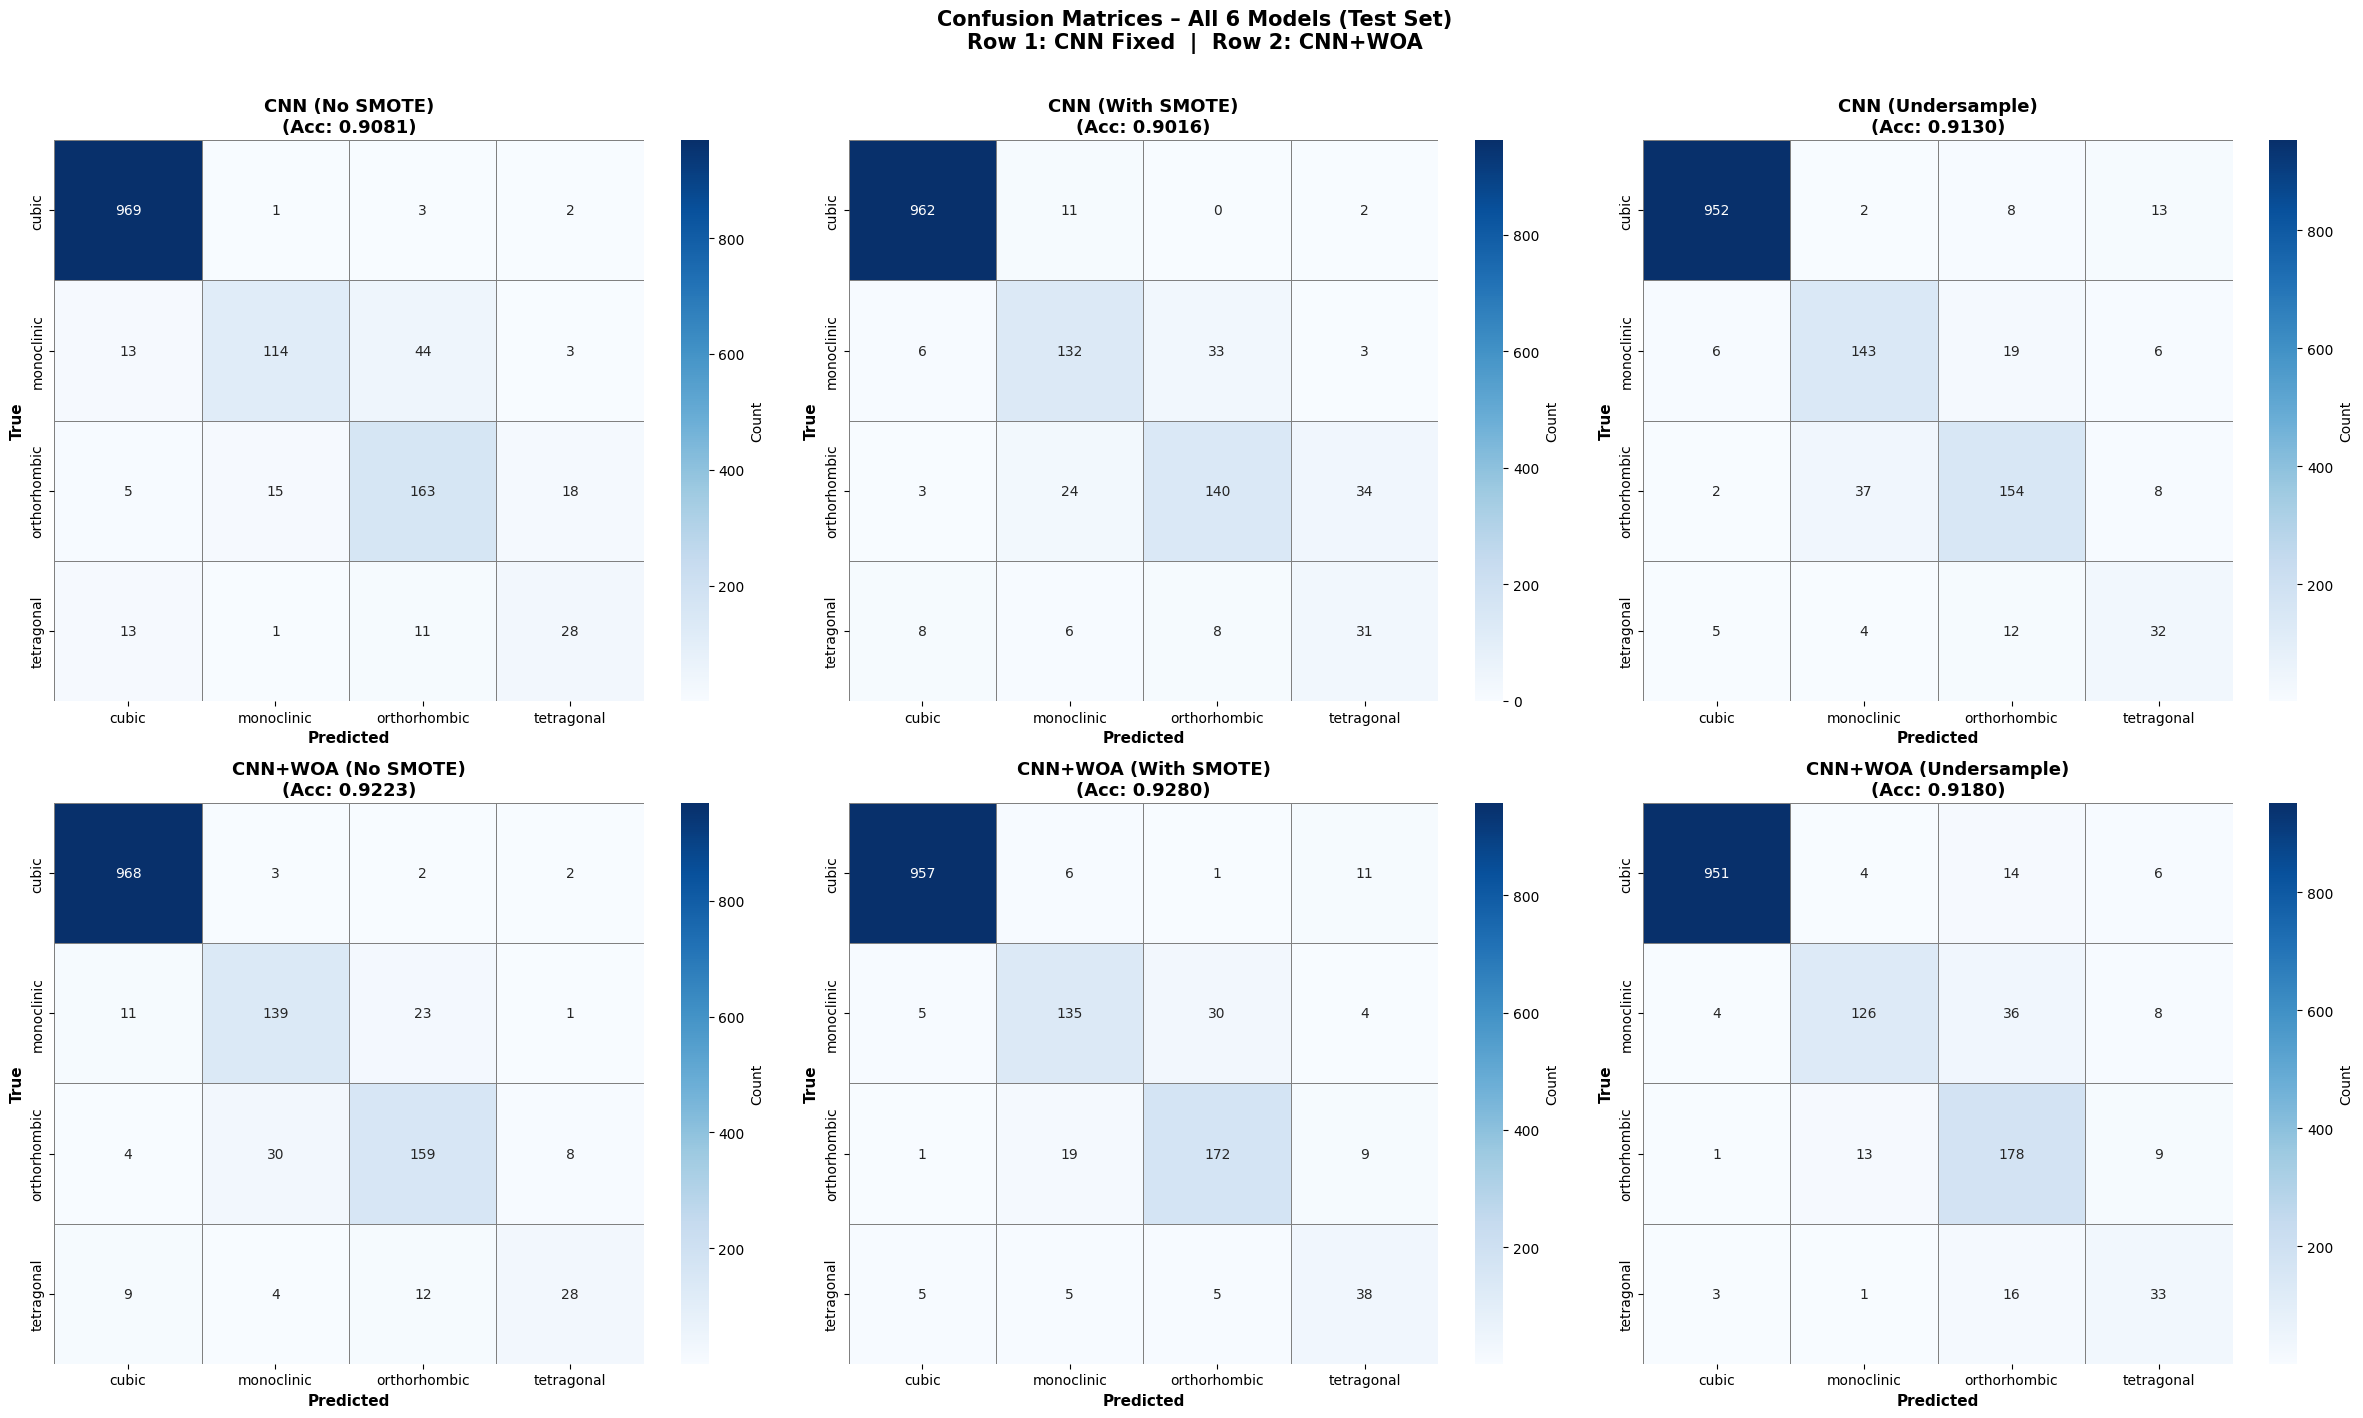

In [ ]:
# ============================================================================
# CONFUSION MATRICES (ALL 6 MODELS)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5,
                linecolor='gray', ax=axes[idx])
    acc = results['accuracy']
    axes[idx].set_title(f'{model_name}\n(Acc: {acc:.4f})',
                        fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices – All 6 Models (Test Set)\n'
             'Row 1: CNN Fixed  |  Row 2: CNN+WOA',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{'='*70}")
    print(f"  {model_name}")
    print(f"{'='*70}")
    print(classification_report(
        y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

  CNN (No SMOTE)
              precision    recall  f1-score   support

       cubic       0.97      0.99      0.98       975
  monoclinic       0.87      0.66      0.75       174
orthorhombic       0.74      0.81      0.77       201
  tetragonal       0.55      0.53      0.54        53

    accuracy                           0.91      1403
   macro avg       0.78      0.75      0.76      1403
weighted avg       0.91      0.91      0.91      1403


  CNN (With SMOTE)
              precision    recall  f1-score   support

       cubic       0.98      0.99      0.98       975
  monoclinic       0.76      0.76      0.76       174
orthorhombic       0.77      0.70      0.73       201
  tetragonal       0.44      0.58      0.50        53

    accuracy                           0.90      1403
   macro avg       0.74      0.76      0.75      1403
weighted avg       0.91      0.90      0.90      1403


  CNN (Undersample)
              precision    recall  f1-

In [ ]:
# ============================================================================
# FEATURE EXTRACTION FOR t-SNE
# ============================================================================

def extract_features(model, X_data):
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feat_model = Model(
        inputs=model.input,
        outputs=model.get_layer("feature_layer").output
    )
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE")
print("="*70)

feat_dict = {}
for model_name, model in eval_models:
    feat_dict[model_name] = extract_features(model, X_test_raw)
    print(f"✓ {model_name:<30}: {feat_dict[model_name].shape}")

print("\n✓ Feature extraction complete!")


EXTRACTING FEATURES FOR t-SNE
✓ CNN (No SMOTE)                : (1403, 64)
✓ CNN (With SMOTE)              : (1403, 64)
✓ CNN (Undersample)             : (1403, 64)
✓ CNN+WOA (No SMOTE)            : (1403, 86)
✓ CNN+WOA (With SMOTE)          : (1403, 59)
✓ CNN+WOA (Undersample)         : (1403, 54)

✓ Feature extraction complete!


In [ ]:
# ============================================================================
# t-SNE TRANSFORMATION
# ============================================================================

print("\n" + "="*70)
print("APPLYING t-SNE TO ALL 6 MODELS")
print("="*70)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30,
            n_iter=1000, verbose=0)

tsne_dict = {}
for model_name, features in feat_dict.items():
    print(f"  t-SNE → {model_name}...")
    tsne_dict[model_name] = tsne.fit_transform(features)

print("\n✓ t-SNE transformation complete!")


APPLYING t-SNE TO ALL 6 MODELS
  t-SNE → CNN (No SMOTE)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE → CNN (With SMOTE)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE → CNN (Undersample)...


...

  t-SNE → CNN+WOA (With SMOTE)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE → CNN+WOA (Undersample)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



✓ t-SNE transformation complete!


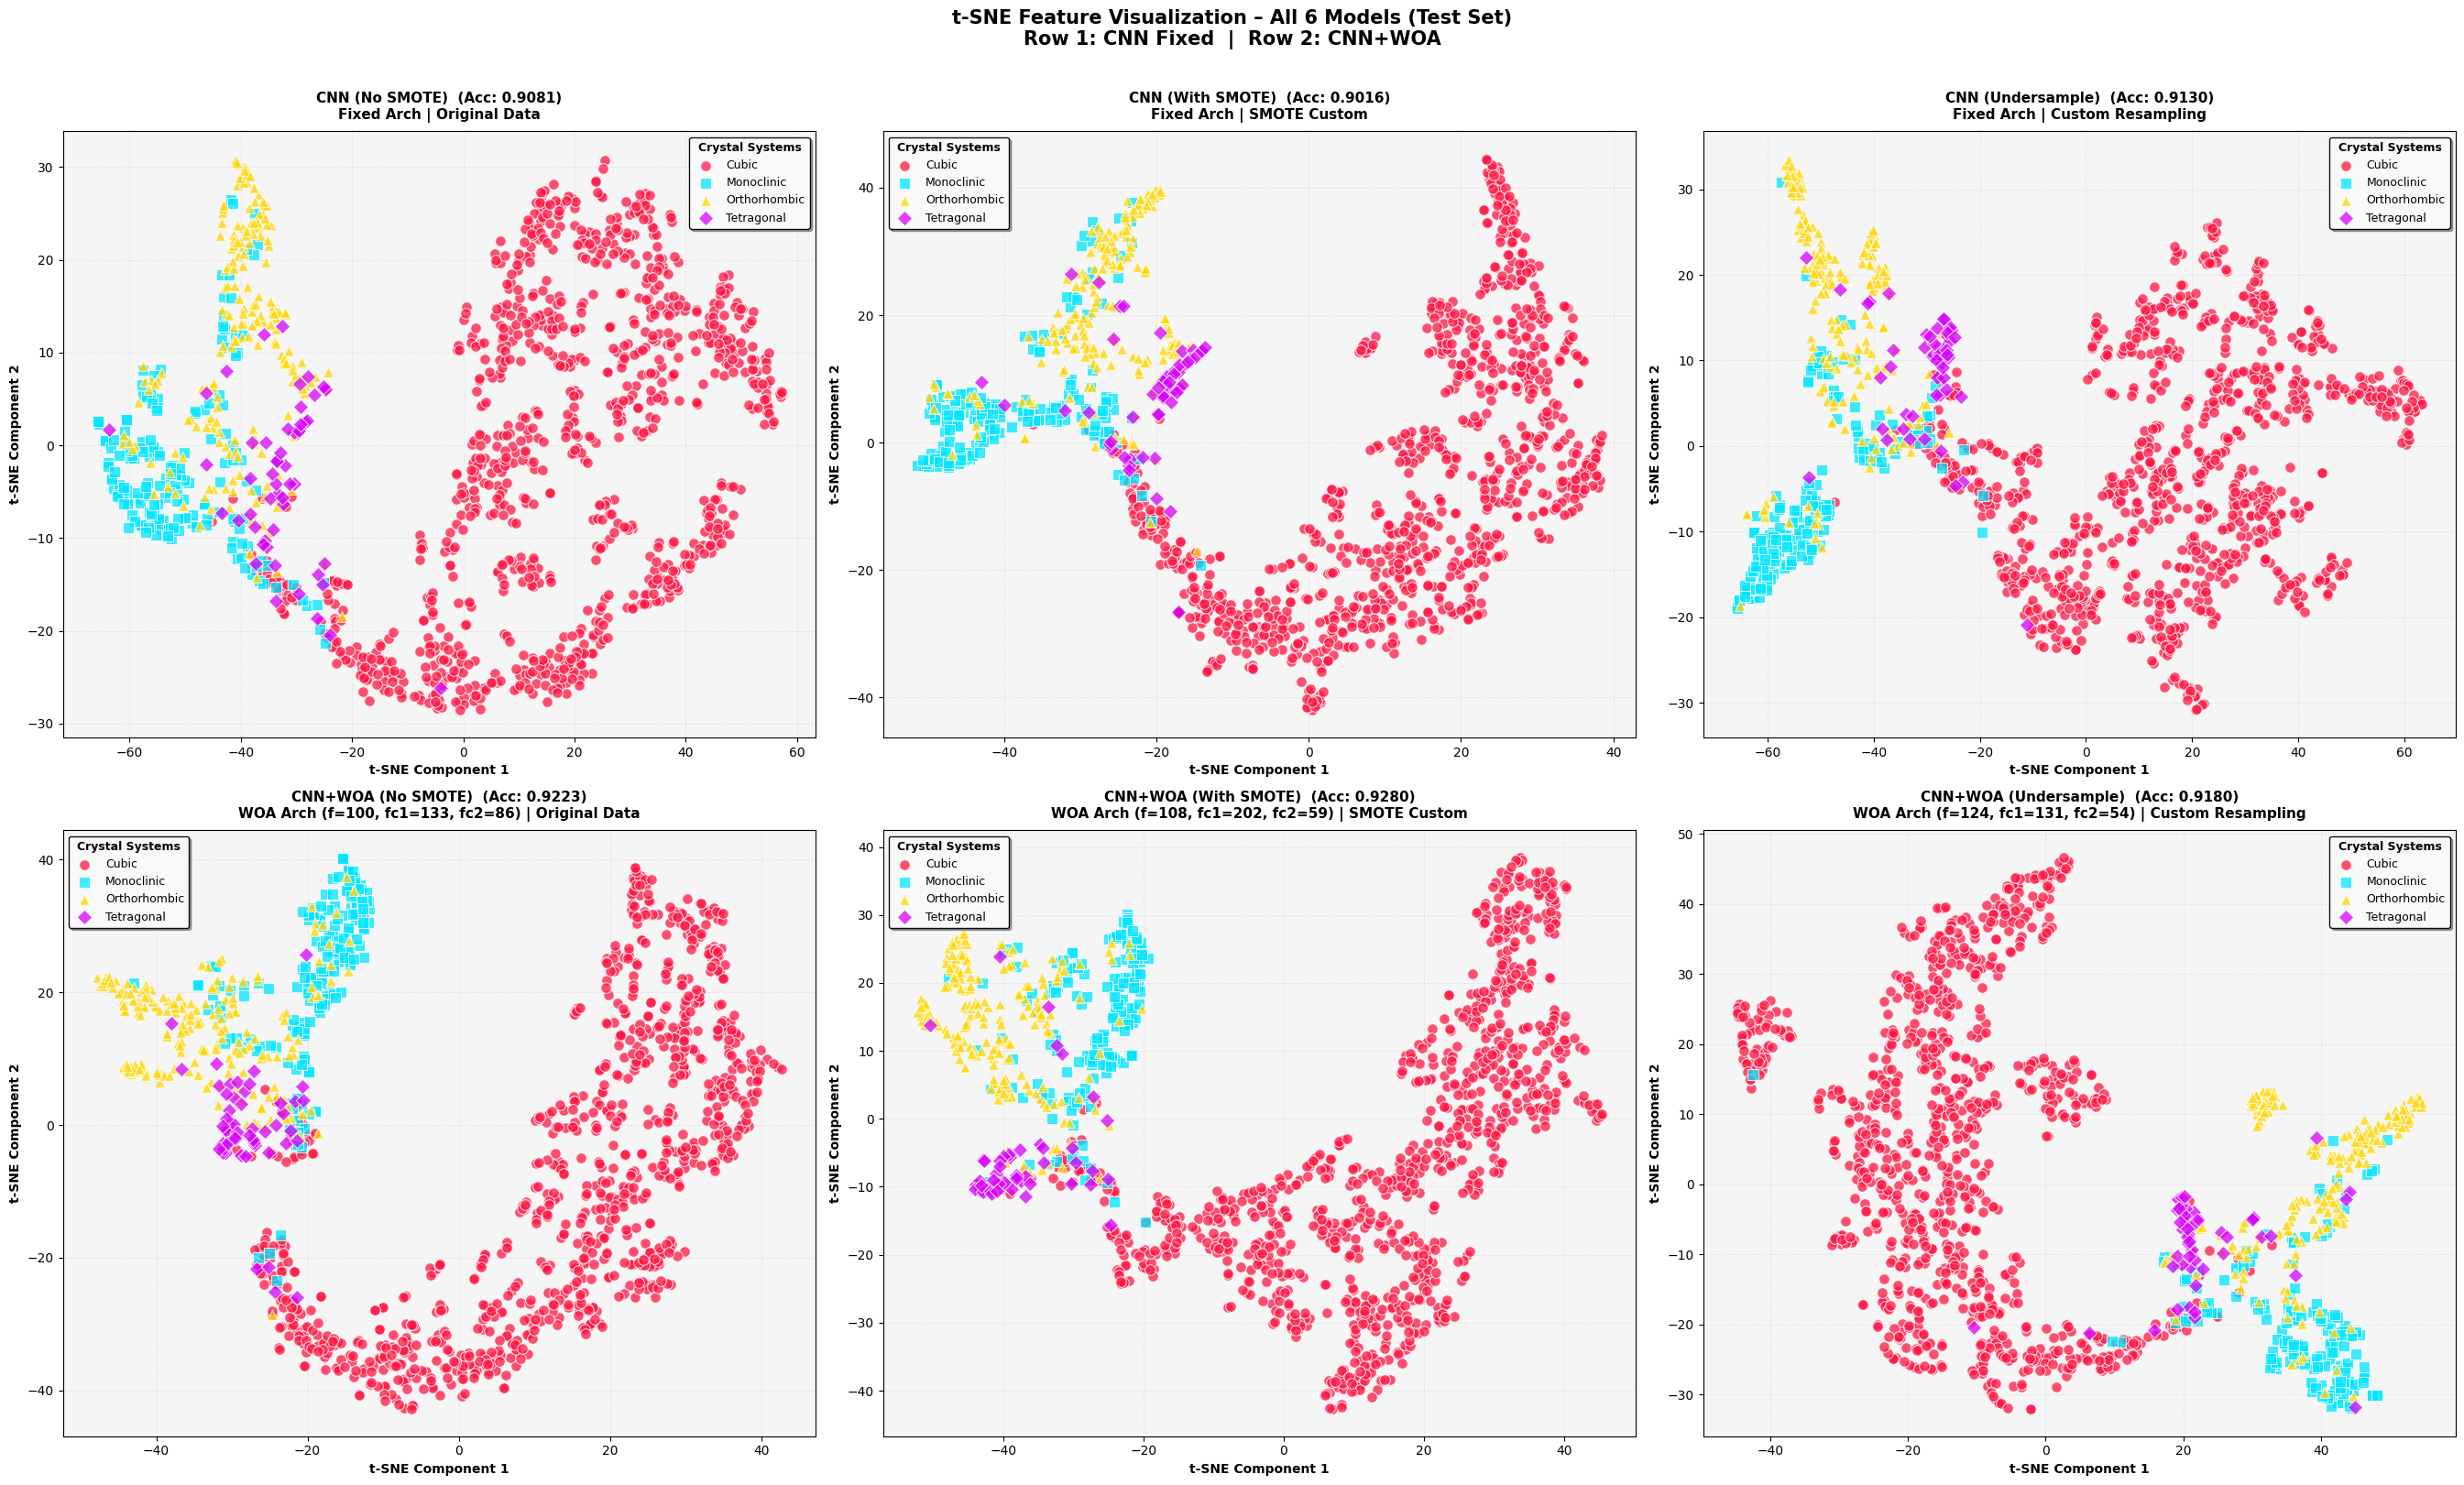


✓ t-SNE visualization complete – 1403 test samples per model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS (ALL 6 MODELS)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(27, 16))
axes = axes.ravel()

colors_bright = ['#FF1744', '#00E5FF', '#FFD600', '#D500F9']
markers       = ['o', 's', '^', 'D']

subtitles = {
    "CNN (No SMOTE)"        : "Fixed Arch | Original Data",
    "CNN (With SMOTE)"      : "Fixed Arch | SMOTE Custom",
    "CNN (Undersample)"     : "Fixed Arch | Custom Resampling",
    "CNN+WOA (No SMOTE)"    : f"WOA Arch (f={int(best_params_no_smote[0])}, "
                               f"fc1={int(best_params_no_smote[1])}, "
                               f"fc2={int(best_params_no_smote[2])}) | Original Data",
    "CNN+WOA (With SMOTE)"  : f"WOA Arch (f={int(best_params_smote[0])}, "
                               f"fc1={int(best_params_smote[1])}, "
                               f"fc2={int(best_params_smote[2])}) | SMOTE Custom",
    "CNN+WOA (Undersample)" : f"WOA Arch (f={int(best_params_undersample[0])}, "
                               f"fc1={int(best_params_undersample[1])}, "
                               f"fc2={int(best_params_undersample[2])}) | Custom Resampling",
}

for idx, (model_name, X_tsne) in enumerate(tsne_dict.items()):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_bright[i], label=name.capitalize(),
                   s=70, alpha=0.75,
                   edgecolors='white', linewidths=0.8,
                   marker=markers[i])

    acc = models_results[model_name]['accuracy']
    ax.set_title(f'{model_name}  (Acc: {acc:.4f})\n{subtitles[model_name]}',
                 fontweight='bold', fontsize=11, pad=10)
    ax.set_xlabel('t-SNE Component 1', fontsize=10, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=10, fontweight='bold')

    legend = ax.legend(fontsize=9, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 9, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Feature Visualization – All 6 Models (Test Set)\n'
             'Row 1: CNN Fixed  |  Row 2: CNN+WOA',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✓ t-SNE visualization complete – {len(X_test)} test samples per model")